In [1]:
import pandas as pd

df = pd.read_csv("train.csv")

label_counts = df['label_id'].value_counts()
label_counts_percentage = df['label_id'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
  "Số id": label_counts,
    "Số %": label_counts_percentage
}
)
print(summary)

          Số id       Số %
label_id                  
0         19886  82.692947
2          2556  10.628743
1          1606   6.678310


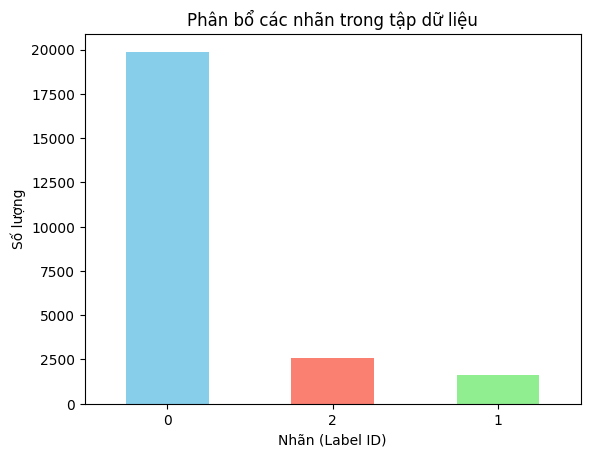

In [2]:
import matplotlib.pyplot as plt


label_counts.plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen'])
plt.title('Phân bổ các nhãn trong tập dữ liệu')
plt.xlabel('Nhãn (Label ID)')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.show()

In [3]:
%pip install underthesea pandas

  Using cached nltk-3.9.2-py3-none-any.whl.metadata (3.2 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 5.4 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.3 MB 8.8 MB/s eta 0:00:01
   --------------------- ------------------ 4.5/8.3 MB 8.7 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 10.3 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 10.3 MB/s  0:00:00
   ---------------------------------------- 0.0/722.6 kB ? eta -:--:--
   ---------------------------------------- 722.6/722.6 kB 17.1 MB/s  0:00:00
Using cached nltk-3.9.2-py3-none-any.whl (1.5 MB)

   -------------------- ------------------- 2/4 [nltk]
   -------------------- ------------------- 2/4 [nltk]
   -------------------- ------------------- 2/4 [nltk]
   -------------------- ------------------- 2/4 [nltk]
   -------------------- ------------------- 2/4 [nltk]
   -------------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import pandas as pd
import random
from underthesea import word_tokenize
from tqdm import tqdm

TARGET_MINORITY = 12000 # Mục tiêu cho HATE và OFFENSIVE
ALPHA = 0.15           # Tỷ lệ alpha theo bài báo
# Từ điển đồng nghĩa (Synonyms) hỗ trợ cho SR và RI
# Bạn nên mở rộng danh sách này dựa trên Annotation Guidelines
SYNONYMS_DICT = {
    "ngu": ["dốt", "kém", "khờ"],
    "xấu": ["tệ", "kém", "tồi"],
    "vcl": ["vãi", "vc", "vkl"],
    "điên": ["khùng", "mất trí"],
    "đẹp": ["xinh", "tươi", "rạng rỡ"]
}

def get_synonyms(word):
    return SYNONYMS_DICT.get(word, [])

# 1. Synonym Substitution (SR) 
def synonym_replacement(words, n):
    new_words = words.copy()
    random_word_list = list(set([word for word in words if word in SYNONYMS_DICT]))
    random.shuffle(random_word_list)
    num_replaced = 0
    for random_word in random_word_list:
        synonyms = get_synonyms(random_word)
        if len(synonyms) >= 1:
            synonym = random.choice(synonyms)
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1
        if num_replaced >= n: break
    return new_words

# 2. Random Deletion (RD) 
def random_deletion(words, p):
    if len(words) == 1: return words
    new_words = [word for word in words if random.uniform(0, 1) > p]
    return new_words if len(new_words) > 0 else [random.choice(words)]

# 3. Random Swap (RS) 
def random_swap(words, n):
    new_words = words.copy()
    for _ in range(n):
        if len(new_words) < 2: break
        idx1, idx2 = random.sample(range(len(new_words)), 2)
        new_words[idx1], new_words[idx2] = new_words[idx2], new_words[idx1]
    return new_words

# 4. Random Insertion (RI) 
def random_insertion(words, n):
    new_words = words.copy()
    for _ in range(n):
        synonyms = []
        target_word = random.choice(new_words)
        synonyms = get_synonyms(target_word)
        if synonyms:
            new_words.insert(random.randint(0, len(new_words)), random.choice(synonyms))
    return new_words

def balance_to_target(df, target_val):
    final_frames = []
    
    # Nhãn 0: Giữ nguyên số lượng gốc (19.886)
    df_0 = df[df['label_id'] == 0]
    final_frames.append(df_0)
    print(f"Nhãn 0 (CLEAN): Giữ nguyên {len(df_0)} mẫu.")

    # Nhãn 1 và 2: Tăng cường lên mức 12.000
    for label in [1, 2]:
        df_label = df[df['label_id'] == label].copy()
        current_count = len(df_label)
        needed = target_val - current_count
        
        print(f"Nhãn {label}: Hiện có {current_count}, cần thêm {needed} mẫu bằng EDA...")
        
        augmented_rows = []
        with tqdm(total=needed) as pbar:
            while len(augmented_rows) < needed:
                # Lấy ngẫu nhiên câu gốc để augment
                row = df_label.sample(n=1).iloc[0]
                new_text = eda_process(row['free_text'])
                
                # Chỉ thêm nếu câu mới khác câu gốc
                if new_text != row['free_text']:
                    augmented_rows.append({'free_text': new_text, 'label_id': label})
                    pbar.update(1)
        
        final_frames.append(df_label)
        final_frames.append(pd.DataFrame(augmented_rows))
            
    return pd.concat(final_frames)

# Thực thi xử lý
df_raw = pd.read_csv("train.csv")
df_final = balance_to_target(df_raw, TARGET_MINORITY)

# Xáo trộn dữ liệu để đảm bảo tính khách quan khi train
df_final = df_final.sample(frac=1).reset_index(drop=True)
df_final.to_csv("train_balanced_12k.csv", index=False, encoding='utf-8-sig')

print(f"\nPhân bổ nhãn cuối cùng:\n{df_final['label_id'].value_counts()}")

Nhãn 0 (CLEAN): Giữ nguyên 19886 mẫu.
Nhãn 1: Hiện có 1606, cần thêm 10394 mẫu bằng EDA...


100%|██████████| 10394/10394 [00:12<00:00, 854.85it/s]


Nhãn 2: Hiện có 2556, cần thêm 9444 mẫu bằng EDA...


100%|██████████| 9444/9444 [00:15<00:00, 593.27it/s]



Phân bổ nhãn cuối cùng:
label_id
0    19886
1    12000
2    12000
Name: count, dtype: int64


In [28]:
import pandas as pd

df = pd.read_csv("train_balanced_12k.csv")

label_counts = df['label_id'].value_counts()
label_counts_percentage = df['label_id'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
  "Số id": label_counts,
    "Số %": label_counts_percentage
}
)
print(summary)

          Số id       Số %
label_id                  
0         19886  45.312856
1         12000  27.343572
2         12000  27.343572


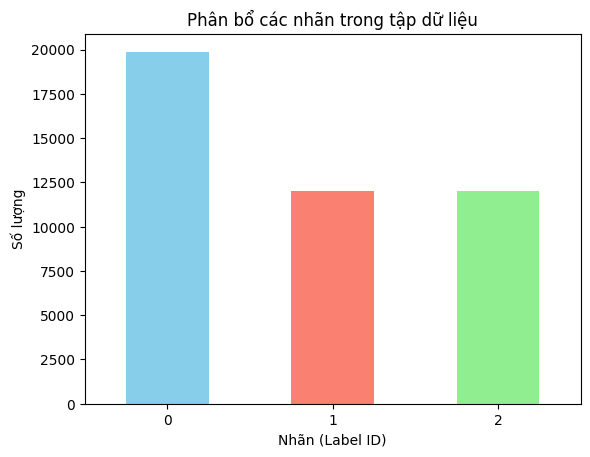

In [29]:
import matplotlib.pyplot as plt


label_counts.plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen'])
plt.title('Phân bổ các nhãn trong tập dữ liệu')
plt.xlabel('Nhãn (Label ID)')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.show()

In [32]:
import pandas as pd
from underthesea import word_tokenize
from collections import Counter

# 1. Đọc dữ liệu
df = pd.read_csv("train_balanced_12k.csv") # Hoặc file dữ liệu của bạn

def get_stats(texts):
    # Tách từ cho toàn bộ các dòng trong nhóm
    tokenized_texts = [word_tokenize(str(text)) for text in texts]
    
    # Tính số lượng từ trong mỗi bình luận
    word_counts = [len(tokens) for tokens in tokenized_texts]
    avg_word_length = sum(word_counts) / len(word_counts) if len(word_counts) > 0 else 0
    
    # Tính Vocab Size (tập hợp các từ duy nhất)
    all_words = [word.lower() for tokens in tokenized_texts for word in tokens]
    vocab_size = len(set(all_words))
    
    return len(texts), avg_word_length, vocab_size

# 2. Thống kê theo từng label_id
results = []
for label in sorted(df['label_id'].unique()):
    subset = df[df['label_id'] == label]['free_text']
    num_comments, avg_len, vocab = get_stats(subset)
    
    label_name = {0: "CLEAN", 1: "OFFENSIVE", 2: "HATE"}.get(label, f"Unknown({label})")
    
    results.append({
        "Label": label_name,
        "Num. Comments": num_comments,
        "Avg. Wordlength": round(avg_len, 2),
        "Vocab.size": vocab
    })

# 3. Hiển thị kết quả dưới dạng bảng
stats_df = pd.DataFrame(results)
print(stats_df.to_string(index=False))

    Label  Num. Comments  Avg. Wordlength  Vocab.size
    CLEAN          19886             9.58       22177
OFFENSIVE          12000            11.84        5007
     HATE          12000            20.01        9439
